In [1]:
import networkx as nx
import matplotlib.pyplot as plt

In [2]:
def gcd_graph(n: int, q: int, S: list[int]) -> nx.Graph:
    '''
    Construct gcd-graph defined on M_n(F_q)
    Args:
    n (int): dimension of matrices
    q (int): order of the finite field F_q
    S (list[int]): list of ranks k in generating set S
    Returns:
    The gcd-graph as a nx.Graph instance
    '''
    F = GF(q)
    MS = MatrixSpace(F, n)
    matrices = list(MS)
    for m in matrices:
        m.set_immutable()
    G = nx.Graph()
    G.add_nodes_from(matrices)
    cardinality = len(matrices)
    for i in range(cardinality):
        for j in range(i+1, cardinality):
            A = matrices[i]
            B = matrices[j]
            if int((A-B).rank()) in S:
                G.add_edge(matrices[i], matrices[j])
    return G

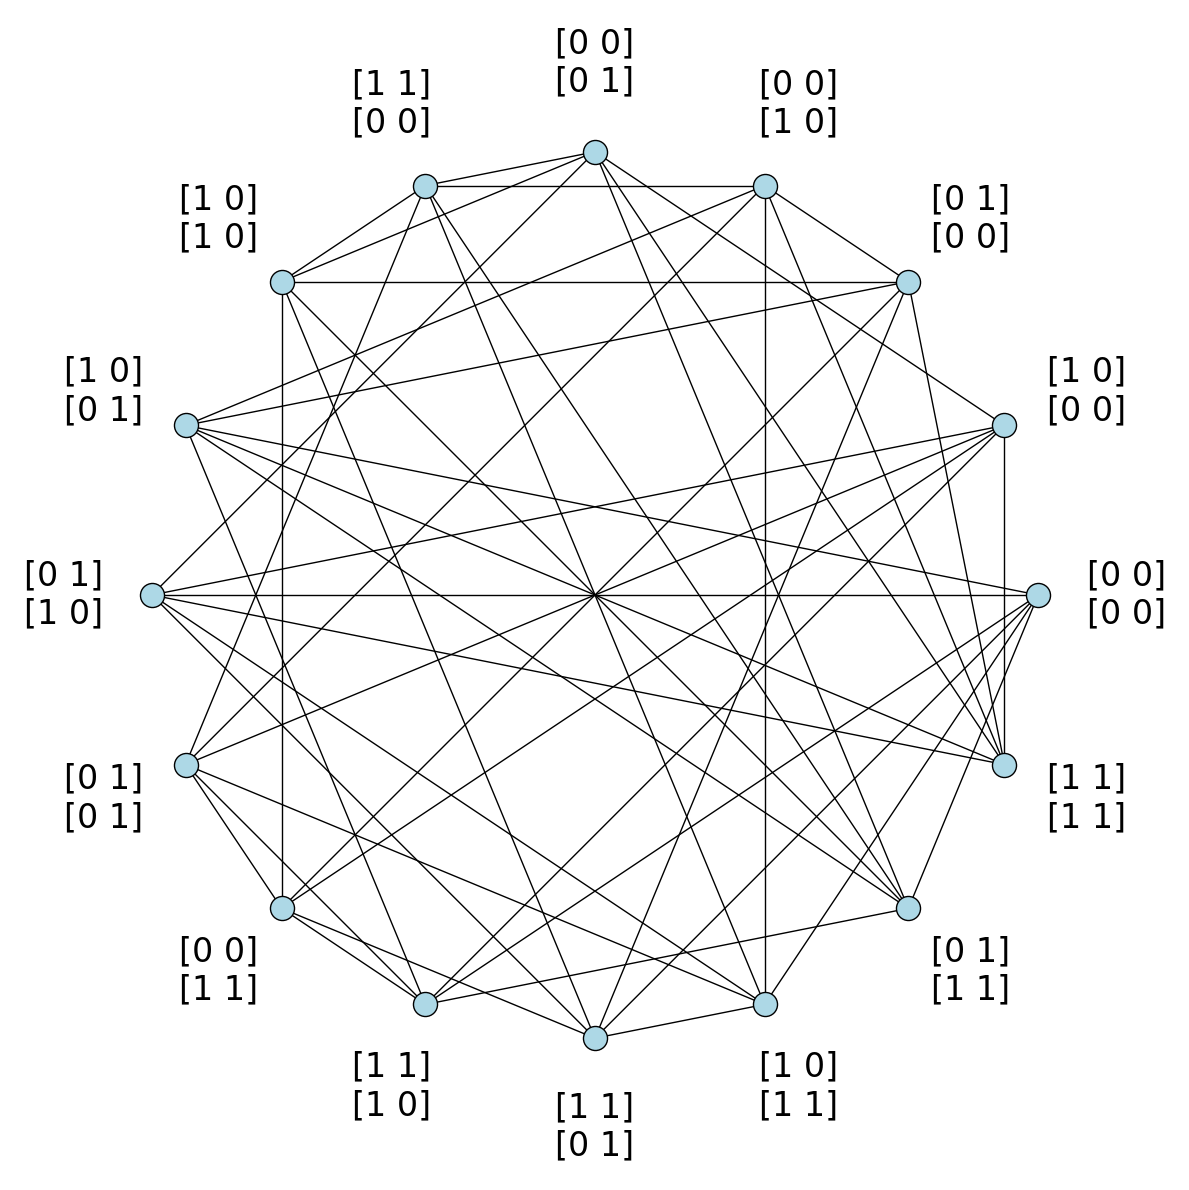

In [3]:
G = gcd_graph(2, 2, [2])

pos = nx.circular_layout(G)
label_pos = {}
for node, (x, y) in pos.items():
    # Multiply by 1.2 to push the label 20% further out from the center
    label_pos[node] = (x * 1.2, y * 1.2)

plt.figure(figsize=(12, 12))

nx.draw_networkx_nodes(G, pos, node_color='lightblue', edgecolors='black')
nx.draw_networkx_edges(G, pos)
nx.draw_networkx_labels(G, label_pos, font_size=24)

plt.margins(0.1)
plt.axis("off")
plt.tight_layout()
plt.savefig("m2f2_2.png", dpi=300)
plt.show()